# 07 — Full CV Results
**BirdCLEF+ 2026 · Baseline EfficientNet-B0 · All 5 Folds**

After training across all 5 folds, this notebook:
1. Overlays training curves from every fold to check consistency
2. Reports the aggregated full-CV macro AUC (all 234 species)
3. Confirms species coverage — are all 234 now evaluable?
4. Updates the per-species AUC breakdown with full data
5. Measures fold stability (per-species AUC variance)
6. Decides whether the baseline is ready for submission

---

In [1]:
import os, sys, warnings
os.chdir(os.path.join(os.path.dirname(os.getcwd()), ''))  # project root
sys.path.insert(0, '.')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.metrics import roc_auc_score
from pathlib import Path

from src.utils.metrics import macro_auc

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (14, 5),
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

# ── Configuration ────────────────────────────────────────────────
PREFIX = 'baseline_effb0'
N_FOLDS = 5
EXP_ROOT = Path('experiments')
ALLFOLDS_DIR = EXP_ROOT / f'{PREFIX}_allfolds'
TRAIN_CSV = Path('data/raw/train.csv')
FOLDS_CSV = Path('data/folds/folds.csv')

# ── Load combined OOF ────────────────────────────────────────────
oof = pd.read_csv(ALLFOLDS_DIR / 'oof_combined.csv')
meta = pd.read_csv(TRAIN_CSV)
folds_df = pd.read_csv(FOLDS_CSV)

species_cols = sorted([c.replace('true_', '') for c in oof.columns if c.startswith('true_')])
print(f'Combined OOF samples : {len(oof)}')
print(f'Species              : {len(species_cols)}')
print(f'Folds present        : {sorted(oof["fold"].unique())}')


Combined OOF samples : 35549
Species              : 234
Folds present        : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


In [2]:
# ── Load all training logs ────────────────────────────────────────
logs = {}
for fold_id in range(N_FOLDS):
    log_path = EXP_ROOT / f'{PREFIX}_fold{fold_id}' / 'training_log.csv'
    if log_path.exists():
        logs[fold_id] = pd.read_csv(log_path)
        print(f'Fold {fold_id}: {len(logs[fold_id])} epochs, '
              f'best AUC = {logs[fold_id]["val_auc"].max():.4f} '
              f'(epoch {logs[fold_id]["val_auc"].idxmax() + 1})')
    else:
        print(f'Fold {fold_id}: training_log.csv NOT FOUND')

print(f'\nLoaded logs for {len(logs)} folds')


Fold 0: 30 epochs, best AUC = 0.9535 (epoch 22)
Fold 1: 30 epochs, best AUC = 0.9535 (epoch 25)
Fold 2: 30 epochs, best AUC = 0.9596 (epoch 22)
Fold 3: 30 epochs, best AUC = 0.9599 (epoch 21)
Fold 4: 30 epochs, best AUC = 0.9620 (epoch 28)

Loaded logs for 5 folds


---
## Section 1 — Training Curves Overlay
Plot all 5 folds' val AUC, train loss, and val loss on shared axes.
Are folds consistent, or is one an outlier?

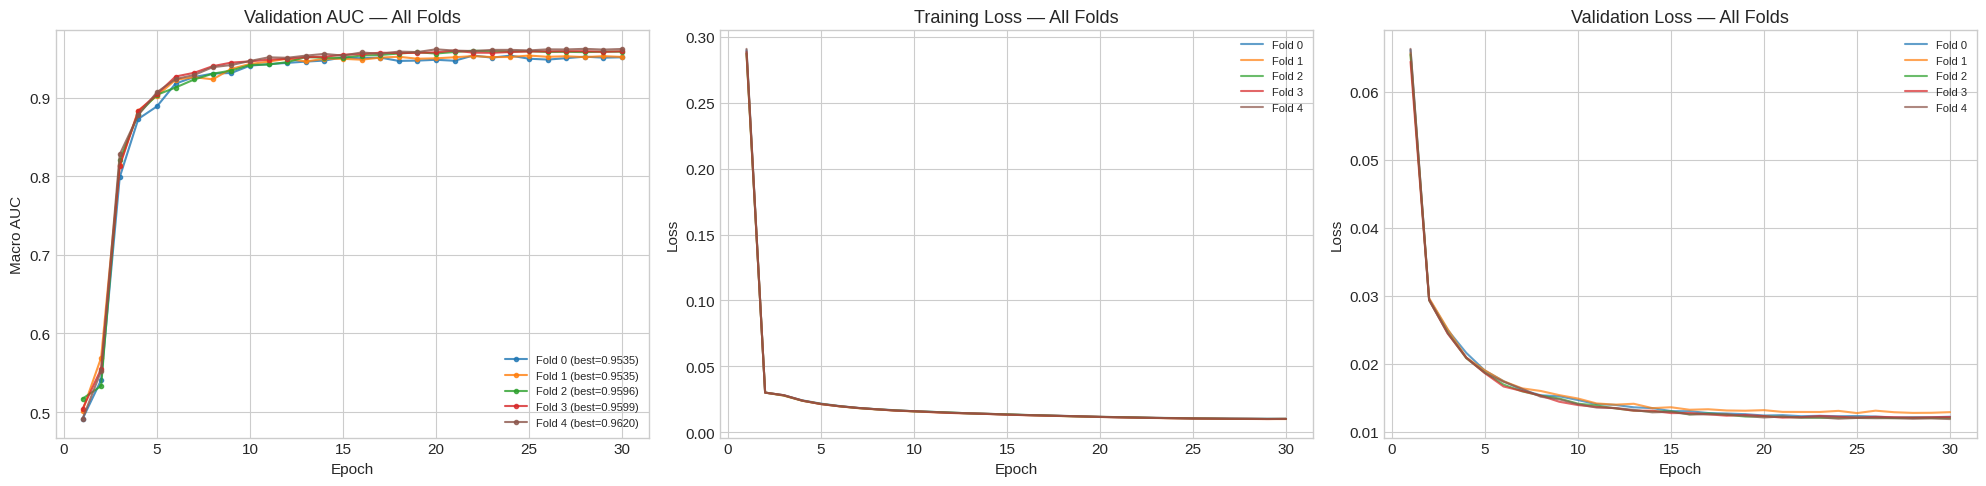

Best AUC range: 0.9535 — 0.9620
Mean ± Std    : 0.9577 ± 0.0035
✓ Folds are very consistent (spread < 0.01)


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fold_colors = plt.cm.tab10(np.linspace(0, 0.5, N_FOLDS))

# ── 1a. Validation AUC ──────────────────────────────────────────
ax = axes[0]
for fid, log in sorted(logs.items()):
    ax.plot(log['epoch'], log['val_auc'], 'o-', color=fold_colors[fid],
            label=f'Fold {fid} (best={log["val_auc"].max():.4f})', markersize=3, alpha=0.8)
ax.set_xlabel('Epoch')
ax.set_ylabel('Macro AUC')
ax.set_title('Validation AUC — All Folds')
ax.legend(fontsize=8)

# ── 1b. Training loss ───────────────────────────────────────────
ax = axes[1]
for fid, log in sorted(logs.items()):
    ax.plot(log['epoch'], log['train_loss'], '-', color=fold_colors[fid],
            label=f'Fold {fid}', alpha=0.7, linewidth=1.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training Loss — All Folds')
ax.legend(fontsize=8)

# ── 1c. Validation loss ─────────────────────────────────────────
ax = axes[2]
for fid, log in sorted(logs.items()):
    ax.plot(log['epoch'], log['val_loss'], '-', color=fold_colors[fid],
            label=f'Fold {fid}', alpha=0.7, linewidth=1.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Validation Loss — All Folds')
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ── Consistency check ────────────────────────────────────────────
best_aucs = {fid: log['val_auc'].max() for fid, log in logs.items()}
auc_vals = list(best_aucs.values())
print(f'Best AUC range: {min(auc_vals):.4f} — {max(auc_vals):.4f}')
print(f'Mean ± Std    : {np.mean(auc_vals):.4f} ± {np.std(auc_vals):.4f}')
spread = max(auc_vals) - min(auc_vals)
if spread < 0.01:
    print('✓ Folds are very consistent (spread < 0.01)')
elif spread < 0.03:
    print('~ Folds are reasonably consistent (spread < 0.03)')
else:
    print('⚠ Significant fold variance detected — investigate outlier folds')


---
## Section 2 — Full CV Score
Compute the definitive macro-averaged ROC-AUC using all OOF predictions.
Compare against the fold-0-only estimate.

In [4]:
# ── Full-dataset macro AUC ────────────────────────────────────────
y_true_all = oof[[f'true_{sp}' for sp in species_cols]].values
y_pred_all = oof[[f'pred_{sp}' for sp in species_cols]].values
full_macro_auc, _ = macro_auc(y_true_all, y_pred_all, species_cols)

# ── Per-fold AUC ─────────────────────────────────────────────────
fold_aucs = {}
for fid in sorted(oof['fold'].unique()):
    fold_oof = oof[oof['fold'] == fid]
    yt = fold_oof[[f'true_{sp}' for sp in species_cols]].values
    yp = fold_oof[[f'pred_{sp}' for sp in species_cols]].values
    fold_auc, _ = macro_auc(yt, yp, species_cols)
    fold_aucs[fid] = fold_auc

# ── Fold-0 reference ────────────────────────────────────────────
fold0_auc = fold_aucs.get(0, np.nan)

print('╔══════════════════════════════════════════════╗')
print(f'║  FULL CV MACRO AUC:  {full_macro_auc:.4f}                  ║')
print('╠══════════════════════════════════════════════╣')
print(f'║  Fold-0 only AUC  :  {fold0_auc:.4f}                  ║')
print(f'║  Delta            :  {full_macro_auc - fold0_auc:+.4f}                  ║')
print('╚══════════════════════════════════════════════╝')
print()
for fid in sorted(fold_aucs.keys()):
    marker = ' ◄ best' if fold_aucs[fid] == max(fold_aucs.values()) else ''
    print(f'  Fold {fid}: {fold_aucs[fid]:.4f}{marker}')
print(f'\n  Mean: {np.mean(list(fold_aucs.values())):.4f}  '
      f'Std: {np.std(list(fold_aucs.values())):.4f}')


╔══════════════════════════════════════════════╗
║  FULL CV MACRO AUC:  0.9475                  ║
╠══════════════════════════════════════════════╣
║  Fold-0 only AUC  :  0.9535                  ║
║  Delta            :  -0.0060                  ║
╚══════════════════════════════════════════════╝

  Fold 0: 0.9535
  Fold 1: 0.9535
  Fold 2: 0.9596
  Fold 3: 0.9599
  Fold 4: 0.9620 ◄ best

  Mean: 0.9577  Std: 0.0035


---
## Section 3 — Species Coverage Check
Confirm all 234 species now have OOF predictions.
Which species were previously unevaluable (on fold 0 alone) and what are their AUCs now?

In [5]:
# ── Per-species AUC on full OOF ───────────────────────────────────
per_sp_full = []
for sp in species_cols:
    y_true = oof[f'true_{sp}'].values
    y_pred = oof[f'pred_{sp}'].values
    n_pos = int(y_true.sum())
    n_neg = int(len(y_true) - n_pos)
    if n_pos == 0 or n_neg == 0:
        auc = np.nan
    else:
        auc = roc_auc_score(y_true, y_pred)
    per_sp_full.append({'species': sp, 'auc_full': auc, 'n_positive': n_pos})

sp_full = pd.DataFrame(per_sp_full)

# ── Per-species AUC on fold-0 only ───────────────────────────────
fold0_oof = oof[oof['fold'] == 0]
per_sp_fold0 = []
for sp in species_cols:
    y_true = fold0_oof[f'true_{sp}'].values
    y_pred = fold0_oof[f'pred_{sp}'].values
    n_pos = int(y_true.sum())
    if n_pos == 0 or int(len(y_true) - n_pos) == 0:
        auc = np.nan
    else:
        auc = roc_auc_score(y_true, y_pred)
    per_sp_fold0.append({'species': sp, 'auc_fold0': auc, 'n_pos_fold0': n_pos})

sp_fold0 = pd.DataFrame(per_sp_fold0)
sp_compare = sp_full.merge(sp_fold0, on='species')

# ── Coverage report ──────────────────────────────────────────────
n_eval_full = sp_compare['auc_full'].notna().sum()
n_eval_fold0 = sp_compare['auc_fold0'].notna().sum()
previously_missing = sp_compare[sp_compare['auc_fold0'].isna() & sp_compare['auc_full'].notna()]
still_missing = sp_compare[sp_compare['auc_full'].isna()]

print(f'Species evaluable with full CV : {n_eval_full} / {len(species_cols)}')
print(f'Species evaluable with fold-0  : {n_eval_fold0} / {len(species_cols)}')
print(f'Newly evaluable species        : {len(previously_missing)}')
print(f'Still missing (full CV)        : {len(still_missing)}')

if len(still_missing) > 0:
    print('\n⚠ Species still without AUC:')
    for _, r in still_missing.iterrows():
        print(f'  • {r["species"]} (n_positive={r["n_positive"]})')

print(f'\n=== Previously unevaluable species — now evaluable ({len(previously_missing)}) ===')
if len(previously_missing) > 0:
    # Merge with metadata for names
    sp_meta = meta.groupby('primary_label').agg(
        common_name=('common_name', 'first'),
        total_samples=('filename', 'count'),
        class_name=('class_name', 'first'),
    ).reset_index().rename(columns={'primary_label': 'species'})
    prev_miss = previously_missing.merge(sp_meta, on='species', how='left')
    prev_miss = prev_miss.sort_values('auc_full', ascending=True)
    for _, r in prev_miss.iterrows():
        name = r.get('common_name', r['species'])
        print(f'  {r["species"]:<30} {name:<30} AUC={r["auc_full"]:.4f}  '
              f'(n_pos={r["n_positive"]}, class={r.get("class_name", "?")})')


Species evaluable with full CV : 206 / 234
Species evaluable with fold-0  : 206 / 234
Newly evaluable species        : 0
Still missing (full CV)        : 28

⚠ Species still without AUC:
  • 1491113 (n_positive=0)
  • 25073 (n_positive=0)
  • 47158son01 (n_positive=0)
  • 47158son02 (n_positive=0)
  • 47158son03 (n_positive=0)
  • 47158son04 (n_positive=0)
  • 47158son05 (n_positive=0)
  • 47158son06 (n_positive=0)
  • 47158son07 (n_positive=0)
  • 47158son08 (n_positive=0)
  • 47158son09 (n_positive=0)
  • 47158son10 (n_positive=0)
  • 47158son11 (n_positive=0)
  • 47158son12 (n_positive=0)
  • 47158son13 (n_positive=0)
  • 47158son14 (n_positive=0)
  • 47158son15 (n_positive=0)
  • 47158son16 (n_positive=0)
  • 47158son17 (n_positive=0)
  • 47158son18 (n_positive=0)
  • 47158son19 (n_positive=0)
  • 47158son20 (n_positive=0)
  • 47158son21 (n_positive=0)
  • 47158son22 (n_positive=0)
  • 47158son23 (n_positive=0)
  • 47158son24 (n_positive=0)
  • 47158son25 (n_positive=0)
  • 517063 

---
## Section 4 — Updated Per-Species AUC Breakdown
Re-run the ranked AUC bar chart from error analysis, now with full-CV data.
Compare the performance distribution to the fold-0-only view.

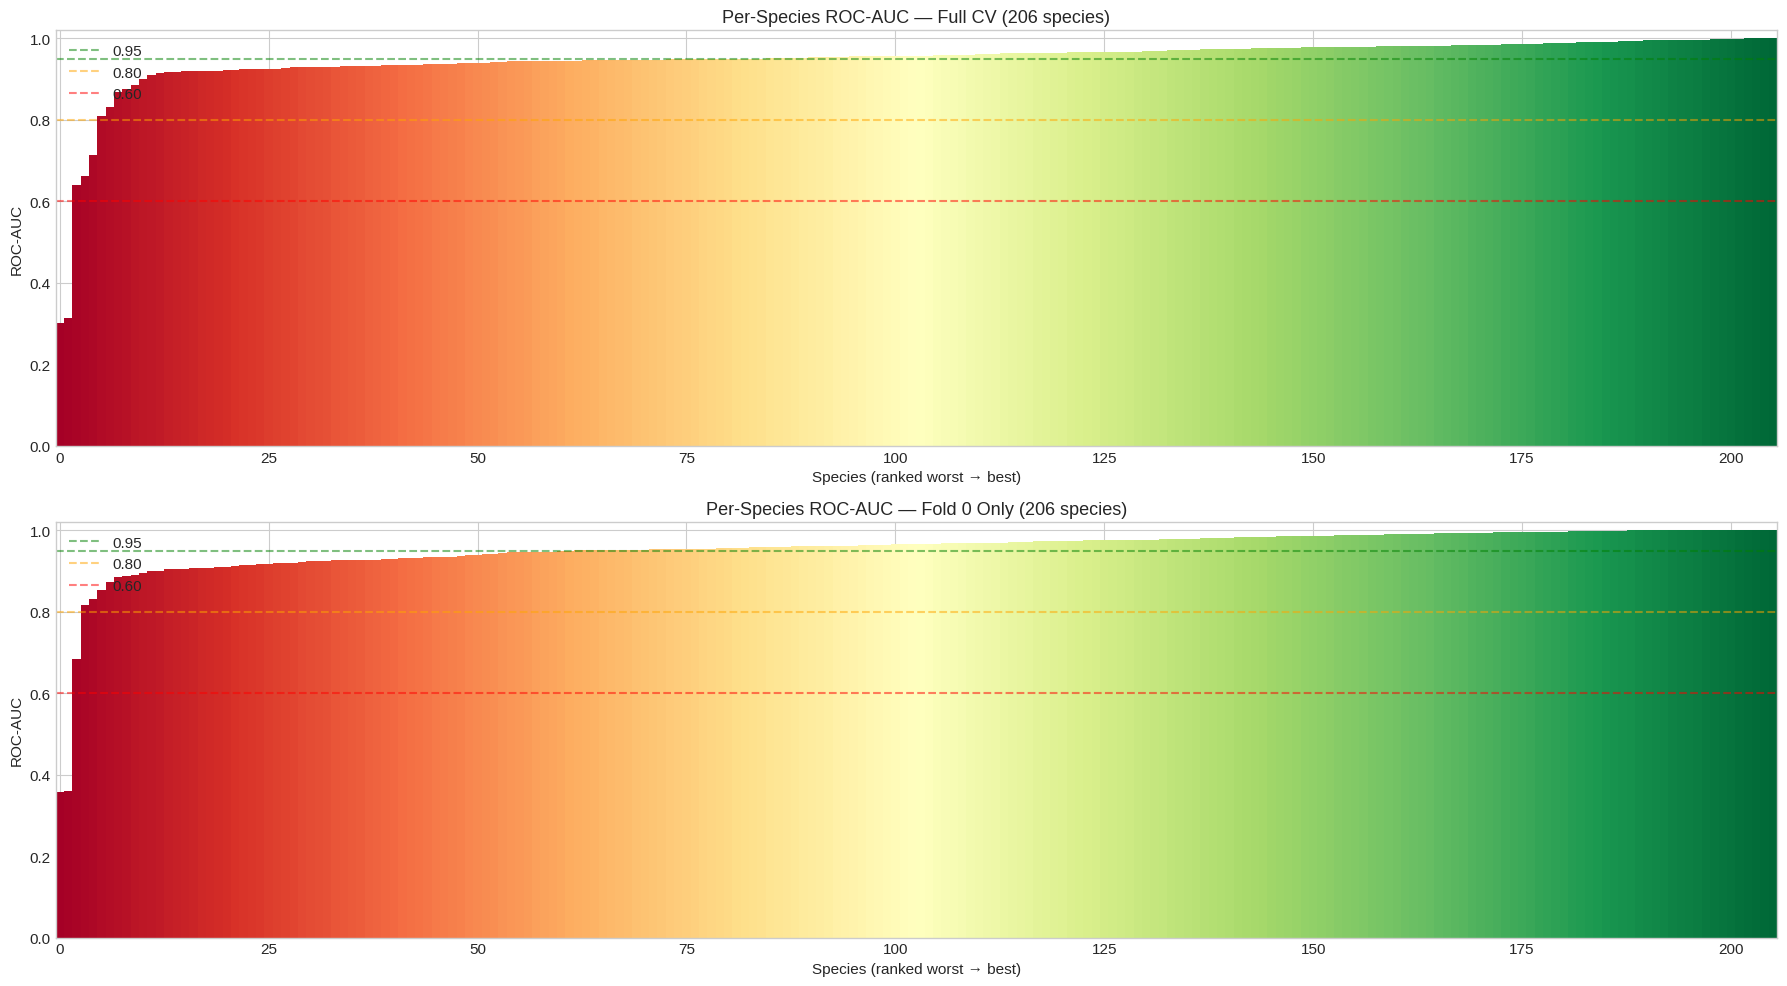

Bucket comparison:
                    Full CV  Fold 0 Only
Strong (≥0.95)          123          145
Decent (0.80–0.95)       78           58
Weak (0.60–0.80)          3            1
Failing (<0.60)           2            2
N/A                      28           28

=== 15 WORST-PERFORMING SPECIES (Full CV) ===
Species                        Name                      Class      AUC_full   AUC_f0  Samples
----------------------------------------------------------------------------------------------------
116570                         Southern Spectacled Caim  Reptilia     0.3013   0.3600        1
23724                          Waxy Monkey Tree Frog     Amphibia     0.3147   0.3569        1
516975                         Hooded Capuchin           Mammalia     0.6404   0.8304        1
74580                          Black-tailed Marmoset     Mammalia     0.6617   0.8523        3
209233                         Feral Horse               Mammalia     0.7144   0.8170        2
23150            

In [6]:
# ── Merge metadata ───────────────────────────────────────────────
sp_meta = meta.groupby('primary_label').agg(
    total_samples=('filename', 'count'),
    mean_rating=('rating', 'mean'),
    class_name=('class_name', 'first'),
    common_name=('common_name', 'first'),
).reset_index().rename(columns={'primary_label': 'species'})

sp_detail = sp_compare.merge(sp_meta, on='species', how='left')

# ── 4a. Ranked bar chart — full CV ──────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(18, 10))

# Full CV
ax = axes[0]
valid_full = sp_detail.dropna(subset=['auc_full']).sort_values('auc_full')
colors = plt.cm.RdYlGn(np.linspace(0, 1, len(valid_full)))
ax.bar(range(len(valid_full)), valid_full['auc_full'].values, color=colors, width=1.0, edgecolor='none')
ax.axhline(0.95, ls='--', color='green', alpha=0.5, label='0.95')
ax.axhline(0.80, ls='--', color='orange', alpha=0.5, label='0.80')
ax.axhline(0.60, ls='--', color='red', alpha=0.5, label='0.60')
ax.set_xlabel('Species (ranked worst → best)')
ax.set_ylabel('ROC-AUC')
ax.set_title(f'Per-Species ROC-AUC — Full CV ({len(valid_full)} species)')
ax.legend()
ax.set_xlim(-0.5, len(valid_full) - 0.5)
ax.set_ylim(0, 1.02)

# Fold-0 only (for comparison)
ax = axes[1]
valid_f0 = sp_detail.dropna(subset=['auc_fold0']).sort_values('auc_fold0')
colors_f0 = plt.cm.RdYlGn(np.linspace(0, 1, len(valid_f0)))
ax.bar(range(len(valid_f0)), valid_f0['auc_fold0'].values, color=colors_f0, width=1.0, edgecolor='none')
ax.axhline(0.95, ls='--', color='green', alpha=0.5, label='0.95')
ax.axhline(0.80, ls='--', color='orange', alpha=0.5, label='0.80')
ax.axhline(0.60, ls='--', color='red', alpha=0.5, label='0.60')
ax.set_xlabel('Species (ranked worst → best)')
ax.set_ylabel('ROC-AUC')
ax.set_title(f'Per-Species ROC-AUC — Fold 0 Only ({len(valid_f0)} species)')
ax.legend()
ax.set_xlim(-0.5, len(valid_f0) - 0.5)
ax.set_ylim(0, 1.02)

plt.tight_layout()
plt.show()

# ── 4b. Bucket comparison ───────────────────────────────────────
def bucket(auc):
    if pd.isna(auc): return 'N/A'
    if auc >= 0.95: return 'Strong (≥0.95)'
    if auc >= 0.80: return 'Decent (0.80–0.95)'
    if auc >= 0.60: return 'Weak (0.60–0.80)'
    return 'Failing (<0.60)'

sp_detail['bucket_full'] = sp_detail['auc_full'].apply(bucket)
sp_detail['bucket_fold0'] = sp_detail['auc_fold0'].apply(bucket)

bucket_order = ['Strong (≥0.95)', 'Decent (0.80–0.95)', 'Weak (0.60–0.80)', 'Failing (<0.60)', 'N/A']
ct_full = sp_detail['bucket_full'].value_counts().reindex(bucket_order, fill_value=0)
ct_f0 = sp_detail['bucket_fold0'].value_counts().reindex(bucket_order, fill_value=0)

compare_df = pd.DataFrame({'Full CV': ct_full, 'Fold 0 Only': ct_f0})
print('Bucket comparison:')
print(compare_df.to_string())

# ── 4c. Worst 15 species (full CV) ──────────────────────────────
print('\n=== 15 WORST-PERFORMING SPECIES (Full CV) ===')
worst15 = sp_detail.dropna(subset=['auc_full']).nsmallest(15, 'auc_full')
print(f"{'Species':<30} {'Name':<25} {'Class':<10} {'AUC_full':>8} {'AUC_f0':>8} {'Samples':>8}")
print('-' * 100)
for _, r in worst15.iterrows():
    f0_str = f'{r["auc_fold0"]:.4f}' if pd.notna(r['auc_fold0']) else '   N/A'
    print(f'{r["species"]:<30} {str(r.get("common_name",""))[:24]:<25} '
          f'{str(r.get("class_name","")):<10} {r["auc_full"]:>8.4f} {f0_str:>8} '
          f'{r["total_samples"]:>8.0f}')


---
## Section 5 — Fold Stability
For each species, compute AUC separately on each fold's OOF predictions.
Flag species with high variance (unstable across folds).

Species evaluable in all 5 folds: 192 / 234
Species evaluable in 0 folds: 28


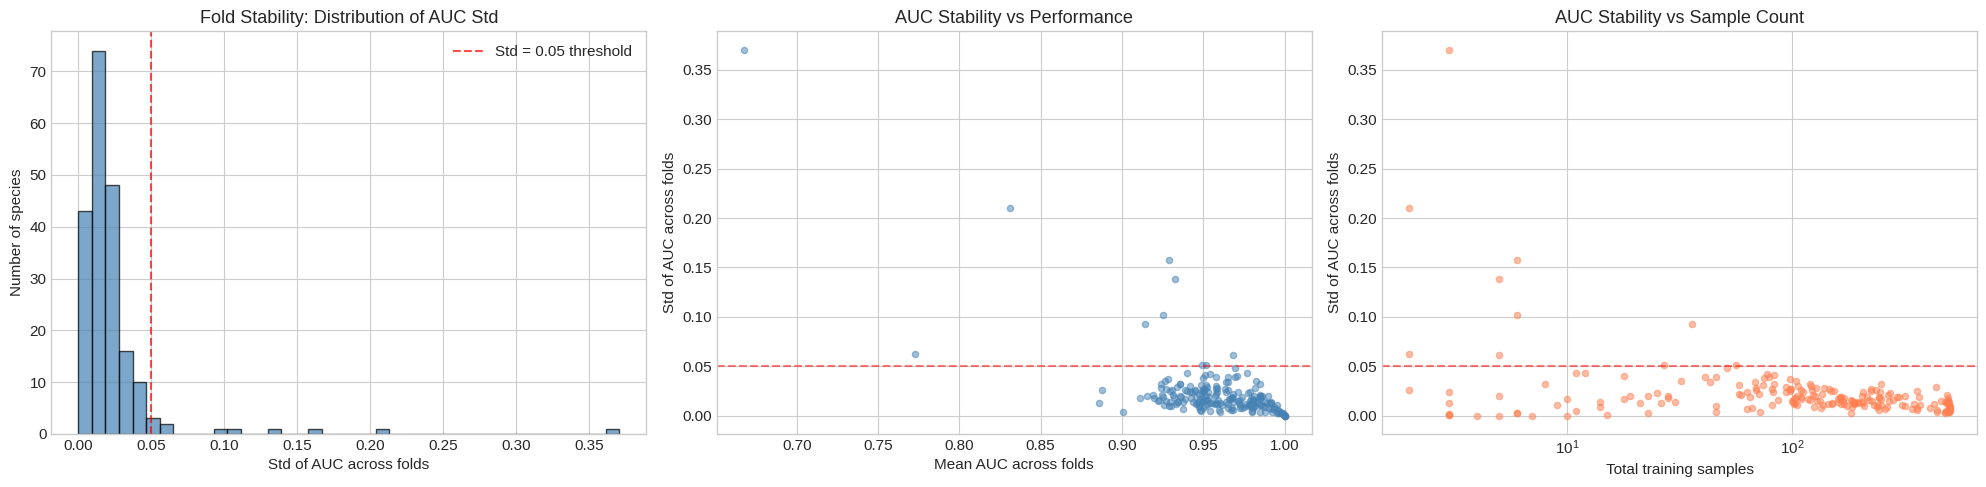


=== UNSTABLE SPECIES (AUC std > 0.05) — 10 species ===
Species                        Name                      Mean AUC    Std  Range F    0 F    1 F    2 F    3 F    4
------------------------------------------------------------------------------------------------------------------------
74580                          Black-tailed Marmoset       0.6675  0.370  0.668 0.852 0.241 0.909   N/A   N/A
70711                          Cei's White-lipped Frog     0.8312  0.210  0.297 0.683 0.980   N/A   N/A   N/A
67252                          Milk Frog                   0.9292  0.158  0.353 1.000 1.000 1.000 0.647 0.999
66971                          Paraguayan Swimming Frog    0.9325  0.138  0.314 0.978 1.000 1.000 1.000 0.686
22985                          Peter's Jungle Frog         0.9252  0.102  0.225 0.994 0.861 0.775 0.995 1.000
platyr1                        Plain Inezia                0.9143  0.093  0.224 0.961 0.945 0.749 0.973 0.944
209233                         Feral Horse      

In [7]:
# ── Per-species, per-fold AUC ─────────────────────────────────────
fold_ids = sorted(oof['fold'].unique())
sp_fold_aucs = []

for sp in species_cols:
    row = {'species': sp}
    for fid in fold_ids:
        fold_oof = oof[oof['fold'] == fid]
        y_true = fold_oof[f'true_{sp}'].values
        y_pred = fold_oof[f'pred_{sp}'].values
        n_pos = int(y_true.sum())
        if n_pos == 0 or int(len(y_true) - n_pos) == 0:
            row[f'auc_fold{fid}'] = np.nan
        else:
            row[f'auc_fold{fid}'] = roc_auc_score(y_true, y_pred)
    sp_fold_aucs.append(row)

sp_stability = pd.DataFrame(sp_fold_aucs)
auc_cols = [f'auc_fold{f}' for f in fold_ids]
sp_stability['auc_mean'] = sp_stability[auc_cols].mean(axis=1)
sp_stability['auc_std'] = sp_stability[auc_cols].std(axis=1)
sp_stability['auc_range'] = sp_stability[auc_cols].max(axis=1) - sp_stability[auc_cols].min(axis=1)
sp_stability['n_folds_evaluable'] = sp_stability[auc_cols].notna().sum(axis=1)

# Merge metadata
sp_stability = sp_stability.merge(
    sp_meta[['species', 'common_name', 'class_name', 'total_samples']], on='species', how='left')

print(f'Species evaluable in all {len(fold_ids)} folds: '
      f'{(sp_stability["n_folds_evaluable"] == len(fold_ids)).sum()} / {len(species_cols)}')
print(f'Species evaluable in 0 folds: {(sp_stability["n_folds_evaluable"] == 0).sum()}')

# ── 5a. Distribution of per-species AUC std ──────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Histogram of std
ax = axes[0]
valid_std = sp_stability.dropna(subset=['auc_std'])
ax.hist(valid_std['auc_std'], bins=40, color='steelblue', edgecolor='black', alpha=0.7)
ax.axvline(0.05, ls='--', color='red', alpha=0.7, label='Std = 0.05 threshold')
ax.set_xlabel('Std of AUC across folds')
ax.set_ylabel('Number of species')
ax.set_title('Fold Stability: Distribution of AUC Std')
ax.legend()

# Std vs mean AUC scatter
ax = axes[1]
ax.scatter(valid_std['auc_mean'], valid_std['auc_std'], alpha=0.5, s=20, color='steelblue')
ax.axhline(0.05, ls='--', color='red', alpha=0.5)
ax.set_xlabel('Mean AUC across folds')
ax.set_ylabel('Std of AUC across folds')
ax.set_title('AUC Stability vs Performance')

# Std vs sample count
ax = axes[2]
ax.scatter(valid_std['total_samples'], valid_std['auc_std'], alpha=0.5, s=20, color='coral')
ax.axhline(0.05, ls='--', color='red', alpha=0.5)
ax.set_xlabel('Total training samples')
ax.set_ylabel('Std of AUC across folds')
ax.set_title('AUC Stability vs Sample Count')
ax.set_xscale('log')

plt.tight_layout()
plt.show()

# ── 5b. Most unstable species ───────────────────────────────────
HIGH_VAR_THRESHOLD = 0.05
unstable = sp_stability[sp_stability['auc_std'] > HIGH_VAR_THRESHOLD].sort_values('auc_std', ascending=False)
print(f'\n=== UNSTABLE SPECIES (AUC std > {HIGH_VAR_THRESHOLD}) — {len(unstable)} species ===')
if len(unstable) > 0:
    print(f"{'Species':<30} {'Name':<25} {'Mean AUC':>8} {'Std':>6} {'Range':>6} " +
          ' '.join([f'F{f:>5}' for f in fold_ids]))
    print('-' * 120)
    for _, r in unstable.head(25).iterrows():
        fold_vals = ' '.join([f'{r[f"auc_fold{f}"]:>5.3f}' if pd.notna(r[f'auc_fold{f}']) else '  N/A' 
                              for f in fold_ids])
        print(f'{r["species"]:<30} {str(r.get("common_name",""))[:24]:<25} '
              f'{r["auc_mean"]:>8.4f} {r["auc_std"]:>6.3f} {r["auc_range"]:>6.3f} {fold_vals}')
else:
    print('  ✓ No species exceed the variance threshold — predictions are stable!')

# ── 5c. Most stable species (for contrast) ──────────────────────
stable = sp_stability[sp_stability['n_folds_evaluable'] == len(fold_ids)].nsmallest(10, 'auc_std')
print(f'\n=== 10 MOST STABLE SPECIES ===')
for _, r in stable.iterrows():
    print(f'  {r["species"]:<30} mean={r["auc_mean"]:.4f}  std={r["auc_std"]:.4f}')


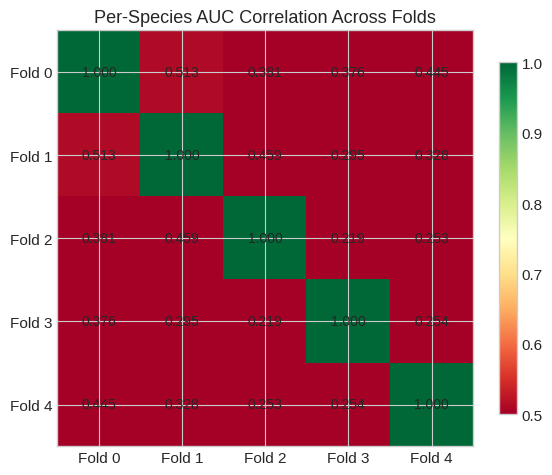

Mean off-diagonal correlation: 0.3524


In [8]:
# ── 5d. Fold-correlation heatmap ──────────────────────────────────
# Are per-species AUCs correlated across folds? (sanity check)
eval_all = sp_stability.dropna(subset=auc_cols)
if len(eval_all) > 10:
    corr = eval_all[auc_cols].corr()
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(corr.values, cmap='RdYlGn', vmin=0.5, vmax=1.0)
    ax.set_xticks(range(len(fold_ids)))
    ax.set_yticks(range(len(fold_ids)))
    ax.set_xticklabels([f'Fold {f}' for f in fold_ids])
    ax.set_yticklabels([f'Fold {f}' for f in fold_ids])
    for i in range(len(fold_ids)):
        for j in range(len(fold_ids)):
            ax.text(j, i, f'{corr.values[i, j]:.3f}', ha='center', va='center', fontsize=10)
    plt.colorbar(im, ax=ax, shrink=0.8)
    ax.set_title('Per-Species AUC Correlation Across Folds')
    plt.tight_layout()
    plt.show()
    print(f'Mean off-diagonal correlation: {corr.values[np.triu_indices(len(fold_ids), k=1)].mean():.4f}')


---
## Section 6 — Summary & Decision

In [9]:
# ── Auto-generate summary ────────────────────────────────────────
from IPython.display import Markdown, display

valid_full = sp_detail.dropna(subset=['auc_full'])
n_strong = (valid_full['auc_full'] >= 0.95).sum()
n_decent = ((valid_full['auc_full'] >= 0.80) & (valid_full['auc_full'] < 0.95)).sum()
n_weak = ((valid_full['auc_full'] >= 0.60) & (valid_full['auc_full'] < 0.80)).sum()
n_failing = (valid_full['auc_full'] < 0.60).sum()

auc_vals = list(fold_aucs.values())
mean_fold_auc = np.mean(auc_vals)
std_fold_auc = np.std(auc_vals)

n_unstable = len(unstable) if 'unstable' in dir() else 0

# Stability verdict
if std_fold_auc < 0.005 and n_unstable < 10:
    stability_verdict = '**Stable.** Low fold-to-fold variance and few unstable species.'
    ready = True
elif std_fold_auc < 0.01:
    stability_verdict = '**Reasonably stable.** Minor variance across folds — acceptable for submission.'
    ready = True
else:
    stability_verdict = '**Unstable.** Significant fold variance — consider investigating before submission.'
    ready = False

summary = f"""
### Final Cross-Validation Report

| Metric | Value |
|--------|-------|
| **Full CV Macro AUC** | **{full_macro_auc:.4f}** |
| Fold-0-only AUC | {fold0_auc:.4f} |
| Mean fold AUC ± std | {mean_fold_auc:.4f} ± {std_fold_auc:.4f} |
| Evaluable species (full CV) | {n_eval_full} / {len(species_cols)} |
| Previously unevaluable | {len(previously_missing)} (now evaluable) |

### Performance Breakdown
| Bucket | Count |
|--------|-------|
| Strong (≥0.95) | {n_strong} |
| Decent (0.80–0.95) | {n_decent} |
| Weak (0.60–0.80) | {n_weak} |
| Failing (<0.60) | {n_failing} |

### Fold Stability
{stability_verdict}
- Unstable species (std > 0.05): {n_unstable}
- Mean fold AUC spread: {max(auc_vals) - min(auc_vals):.4f}

### Decision
{'**✓ Baseline is stable enough to proceed to the inference/submission phase.**' if ready else '**⚠ Baseline needs improvement before submission — address high-variance species.**'}

With {len(fold_ids)} trained checkpoints and a full CV score of **{full_macro_auc:.4f}**,
the next steps are:
1. Build the CPU inference pipeline (ensemble of {len(fold_ids)} fold models)
2. Create the Kaggle submission notebook (90-minute CPU constraint)
3. Submit and establish a leaderboard baseline

If further improvement is desired before submission, the highest-impact experiments
(from notebook 06) are: focal loss / class-weighted BCE for rare species, and a
stronger backbone (EfficientNet-B2 or ConvNeXt-Tiny).
"""
display(Markdown(summary))



### Final Cross-Validation Report

| Metric | Value |
|--------|-------|
| **Full CV Macro AUC** | **0.9475** |
| Fold-0-only AUC | 0.9535 |
| Mean fold AUC ± std | 0.9577 ± 0.0035 |
| Evaluable species (full CV) | 206 / 234 |
| Previously unevaluable | 0 (now evaluable) |

### Performance Breakdown
| Bucket | Count |
|--------|-------|
| Strong (≥0.95) | 123 |
| Decent (0.80–0.95) | 78 |
| Weak (0.60–0.80) | 3 |
| Failing (<0.60) | 2 |

### Fold Stability
**Reasonably stable.** Minor variance across folds — acceptable for submission.
- Unstable species (std > 0.05): 10
- Mean fold AUC spread: 0.0086

### Decision
**✓ Baseline is stable enough to proceed to the inference/submission phase.**

With 5 trained checkpoints and a full CV score of **0.9475**,
the next steps are:
1. Build the CPU inference pipeline (ensemble of 5 fold models)
2. Create the Kaggle submission notebook (90-minute CPU constraint)
3. Submit and establish a leaderboard baseline

If further improvement is desired before submission, the highest-impact experiments
(from notebook 06) are: focal loss / class-weighted BCE for rare species, and a
stronger backbone (EfficientNet-B2 or ConvNeXt-Tiny).


---
*End of notebook 07 — Full CV Results.*
*Next step: build the CPU inference pipeline and make the first Kaggle submission.*